<a href="https://colab.research.google.com/github/241b163-dot/algo/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Searching
Implement Linear Search. Determine the time required to search for element. Repeat the experiment for different values of n, the number of elements in the list to besearched and plot a graph of the time taken versus n.

- To implement Linear Search, measure its time complexity for searching an element, vary the input size by changing the number of elements in the list, and plot a graph to visualize the relationship between time taken and input size
- Algorithm:  
1. Start with the first element of the list.
2. Compare the element with the value being searched for.
3. If the element matches, return the index.
4. If the element does not match, move to the next element and repeat steps 2-3.
5. If the end of the list is reached and no match is found, return -1

- **Created by Dr. Ajay

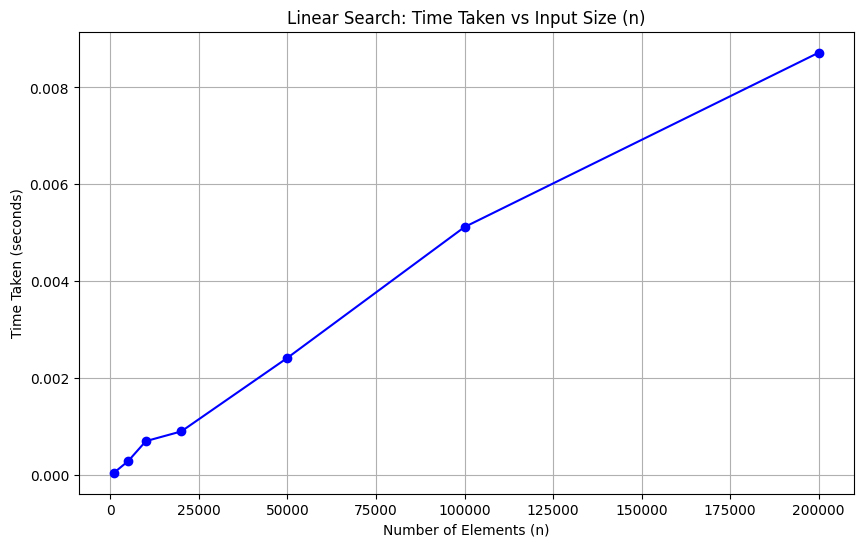

In [1]:
# write code for Linear Search and plot a graph to visualize the relationship between time taken and input size
import time
import matplotlib.pyplot as plt
import random

# 1. Implementation of Linear Search
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

# 2. Experimentation Setup
n_values = [1000, 5000, 10000, 20000, 50000, 100000, 200000]
times = []

for n in n_values:
    # Generate a list of size n
    test_list = list(range(n))
    # Search for an element not in the list to simulate worst-case scenario
    target = -1

    start_time = time.time()
    linear_search(test_list, target)
    end_time = time.time()

    times.append(end_time - start_time)

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_values, times, marker='o', linestyle='-', color='b')
plt.title('Linear Search: Time Taken vs Input Size (n)')
plt.xlabel('Number of Elements (n)')
plt.ylabel('Time Taken (seconds)')
plt.grid(True)
plt.show()


# 2. Searching
Implement recursive Binary Search. Determine the time required to search an element.Repeat the experiment for different values of n, the number of elements in the list to besearched and plot a graph of the time taken versus n.
- implement recursive Binary Search, measure its time complexity for searching an element and plot a graph of time taken versus different values of n, the number of elements in the list.  
Algorithm:
1. Start with the middle element of the list
2. If the middle element matches the element being searched, return the index of the middle element
3. If the middle element is greater than the element being searched, recursively call the function on the left half of the list
4. If the middle element  is  less than the element  being searched, recursively call the function on the right half of the list
5. If the element is not found, return -1

Sizes: [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000]
Times: [1.4334899998402761e-06, 2.0148400000152834e-06, 2.1447599999646626e-06, 2.6428800001099263e-06, 3.595519999919361e-06, 3.1083199999670797e-06, 9.520039999983965e-06, 3.886599999987084e-06, 4.178279999962342e-06]


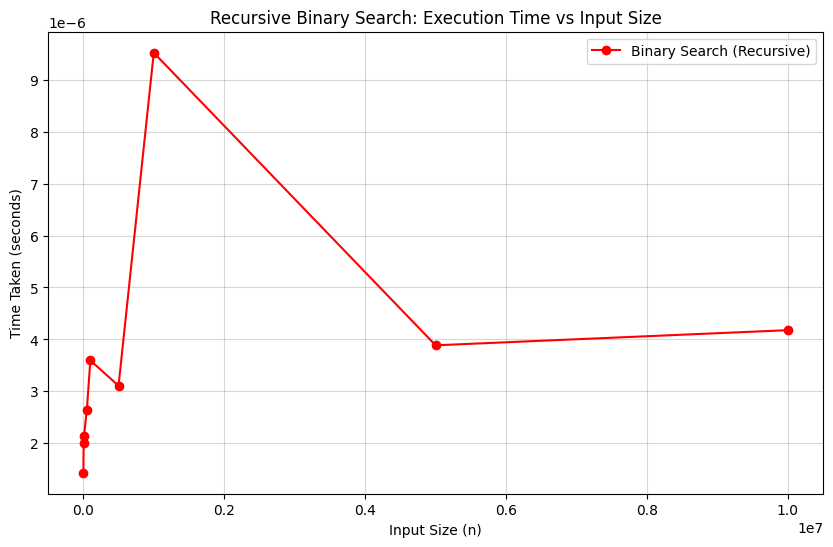

In [2]:
#Prob_2: write code for recursive Binary Search and plot a graph to visualize the relationship between time taken and input size
import time
import matplotlib.pyplot as plt
import numpy as np

# Recursive Binary Search implementation
def binary_search_recursive(arr, low, high, target):
    if low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] > target:
            return binary_search_recursive(arr, low, mid - 1, target)
        else:
            return binary_search_recursive(arr, mid + 1, high, target)
    else:
        return -1

# Performance testing
def measure_performance():
    # Larger sizes to see the O(log n) trend more clearly
    # However, Python's recursion limit might be an issue if n is huge and we go deep,
    # but for log2(10^7) it is only ~23, so it's fine.
    input_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000]
    times = []

    for n in input_sizes:
        arr = list(range(n))
        target = -1 # Worst case: target not in list

        # Measure time multiple times and take average for stability
        iterations = 100
        start_time = time.perf_counter()
        for _ in range(iterations):
            binary_search_recursive(arr, 0, len(arr) - 1, target)
        end_time = time.perf_counter()

        avg_time = (end_time - start_time) / iterations
        times.append(avg_time)

    return input_sizes, times

input_sizes, times = measure_performance()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(input_sizes, times, marker='o', linestyle='-', color='r', label='Binary Search (Recursive)')
plt.title('Recursive Binary Search: Execution Time vs Input Size')
plt.xlabel('Input Size (n)')
plt.ylabel('Time Taken (seconds)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.savefig('binary_search_performance.png')

print(f"Sizes: {input_sizes}")
print(f"Times: {times}")

#Prob-3
Given a text txt [0...n-1] and a pattern pat [0...m-1], write a function search (char pat [ ],char txt [ ]) that prints all occurrences of pat [ ] in txt [ ]. You may assume that n > m.
- Aim:  To write a function "search" that takes a pattern and a text as input, and outputs all occurrences of the pattern in the text.  Algorithm:
1. Initialize an empty list to store the indices where the pattern occurs in the text.
2. Loop through each character in the text. For each character, check if the substring starting at that character matches the pattern.
3. If there is a match, append the starting index of the substring to the list of occurrences.
4. Continue looping through the text until all possible substrings have been checked.
5. Return the list of indices where the pattern occurs in the text.  




In [3]:
#write code for Prob-3
def search(pat, txt):
    """
    Prints all occurrences of pattern 'pat' in text 'txt'
    """
    m = len(pat)
    n = len(txt)
    occurrences = []

    # Slide the pattern over the text one by one
    # We only need to go up to n - m because a pattern of length m
    # cannot fit in a remaining text smaller than m.
    for i in range(n - m + 1):

        # Check for pattern match at the current index i
        match = True
        for j in range(m):
            if txt[i + j] != pat[j]:
                match = False
                break

        # If the pattern matches, store the index
        if match:
            occurrences.append(i)
            print(f"Pattern found at index {i}")

    return occurrences

# --- Example Usage ---
text_input = "ABAAABCDABC"
pattern_input = "ABC"

print(f"Searching for '{pattern_input}' in '{text_input}':")
indices = search(pattern_input, text_input)

if not indices:
    print("No occurrences found.")

Searching for 'ABC' in 'ABAAABCDABC':
Pattern found at index 4
Pattern found at index 8


Size 100 sorted in 0.0002s
Size 500 sorted in 0.0056s
Size 1000 sorted in 0.0272s
Size 2000 sorted in 0.0961s
Size 3000 sorted in 0.2278s
Size 4000 sorted in 0.4514s
Size 5000 sorted in 1.2379s


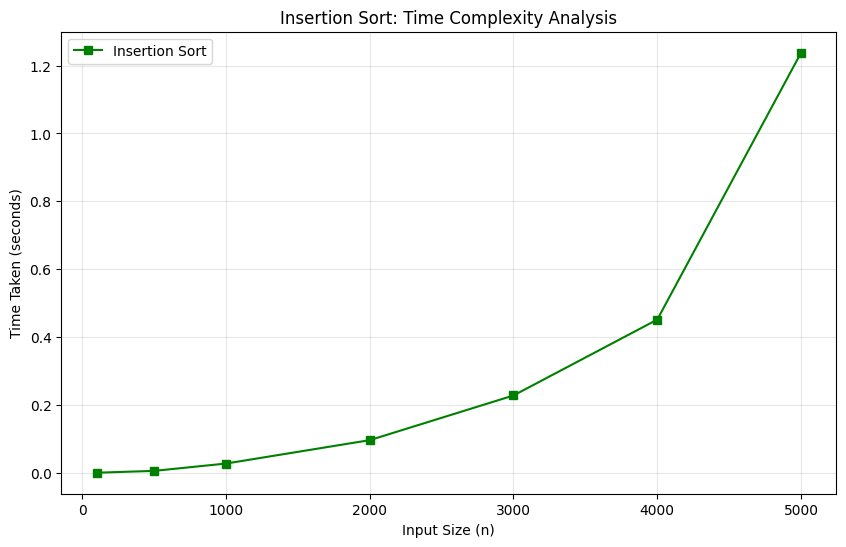

In [4]:
#Prob_4: write code for insertion sort and plot a graph to visualize the relationship between time taken and input size
import time
import matplotlib.pyplot as plt
import random

# 1. Implementation of Insertion Sort
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        # Move elements of arr[0..i-1] that are greater than key
        # to one position ahead of their current position
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

# 2. Performance Measurement Setup
def measure_insertion_sort():
    # Smaller input sizes compared to Binary Search because O(n^2) is slow
    input_sizes = [100, 500, 1000, 2000, 3000, 4000, 5000]
    times = []

    for n in input_sizes:
        # Generate a random list of size n
        test_list = [random.randint(0, 10000) for _ in range(n)]

        start_time = time.time()
        insertion_sort(test_list)
        end_time = time.time()

        times.append(end_time - start_time)
        print(f"Size {n} sorted in {end_time - start_time:.4f}s")

    return input_sizes, times

# 3. Plotting the results
sizes, execution_times = measure_insertion_sort()

plt.figure(figsize=(10, 6))
plt.plot(sizes, execution_times, marker='s', linestyle='-', color='green', label='Insertion Sort')
plt.title('Insertion Sort: Time Complexity Analysis')
plt.xlabel('Input Size (n)')
plt.ylabel('Time Taken (seconds)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()